# 03 - A2C LunarLander con ricerca degli iperparametri

Questo notebook e' un esercizio extra: mantiene separata la baseline A2C LunarLander dal processo di ricerca degli iperparametri. L'obiettivo non e' nascondere la scelta dei parametri, ma renderla riproducibile e confrontabile con una configurazione manuale.

## Strategia

La baseline fa riferimento al file `config_lunarlander.yaml`.

Come esperimento, abbiamo impostato una **ricerca degli iperparametri semplificata** definendo uno spazio di HPO focalizzato e un budget ridotto a **600 episodi per trial** (con pruner mediano a partire dall'episodio 150) per contenere i tempi di addestramento.

Al termine dello studio di Optuna, la configurazione ottimale selezionata viene confermata su **1500 episodi** e testata su più seed per verificarne la stabilità e la generalizzabilità, confrontando infine i risultati ottenuti con la baseline.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import yaml

current_dir = Path.cwd().resolve()
for candidate in [current_dir, *current_dir.parents]:
    if (candidate / "DLA_LAB3" / "src").exists():
        project_root = candidate
        break
else:
    raise RuntimeError("Eseguire il notebook dalla repository Deep_Learning_Laboratories.")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from DLA_LAB3.src.a2c_tuning import (
    build_a2c_lunarlander_config,
    run_a2c_lunarlander_config,
    run_a2c_lunarlander_study,
)
from DLA_LAB3.src.utils import get_device

In [2]:
config_dir = project_root / "DLA_LAB3" / "exercise_3_1_a2c"

with (config_dir / "config_lunarlander.yaml").open("r", encoding="utf-8") as file:
    BASE_CONFIG = yaml.safe_load(file)

with (config_dir / "config_lunarlander_hpo.yaml").open("r", encoding="utf-8") as file:
    HPO_CONFIG = yaml.safe_load(file)

device = get_device(force_cpu=BASE_CONFIG["training"]["force_cpu"])
BASE_CONFIG["training"], HPO_CONFIG, device

({'seeds': [42, 123, 314],
  'num_episodes': 1200,
  'gamma': 0.995,
  'learning_rate': 0.0005,
  'hidden_dim': 128,
  'rollout_steps': 5,
  'vectorized': True,
  'num_envs': 8,
  'vector_env_type': 'sync',
  'value_loss_weight': 1.0,
  'standardize_advantages': True,
  'standardize_critic_targets': True,
  'entropy_weight': 1e-05,
  'force_cpu': True},
 {'study': {'n_trials': 20, 'n_jobs': -1, 'seed': 42},
  'trial_budget': {'num_episodes': 600,
   'eval_every_n': 50,
   'eval_episodes_m': 5},
  'confirmation': {'seeds': [42, 123, 314],
   'num_episodes': 1500,
   'eval_episodes_m': 20}},
 device(type='cpu'))

## Baseline

Riporto prima la baseline dichiarata nel file YAML principale. Questa run resta il riferimento da battere: se Optuna trova una configurazione migliore, deve essere confrontata con questa baseline usando la stessa metrica finale.

In [3]:
baseline_seed = BASE_CONFIG["training"]["seeds"][0]
baseline_output = run_a2c_lunarlander_config(
    config=BASE_CONFIG,
    seed=baseline_seed,
    device=device,
)

baseline_table = pd.DataFrame([baseline_output.summary])
display(baseline_table)

,Seed,Final Train Reward,Best Train Reward,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length,Best Checkpoint Episode,Best Checkpoint Reward
0,42,-116.4,182.7,-37.4,-146.6,170.8,596.1,400,-14.8


## Ricerca Optuna

La ricerca viene eseguita con Optuna impostando uno studio orientato alla massimizzazione del miglior reward medio di valutazione deterministica periodica.

Lo spazio di ricerca HPO configurato per i parametri di A2C è il seguente:
* **`num_envs`** (Categorico): `[1, 4, 8]` (numero di ambienti paralleli)
* **`learning_rate`** (Log-uniforme): `1e-4` a `1e-3` (tasso di apprendimento dell'ottimizzatore Adam)
* **`hidden_dim`** (Categorico): `[64, 128, 256]` (dimensione dei layer lineari di Policy e Value network)
* **`rollout_steps`** (Categorico): `[5, 10, 20]` (lunghezza dell'orizzonte temporale n-step per il bootstrap del Critic)
* **`value_loss_weight`** (Uniforme): `0.25` a `1.0` (peso relativo dell'errore del Critic nella loss totale)
* **`entropy_weight`** (Uniforme): `0.0` a `0.01` (peso del coefficiente di entropia per incoraggiare l'esplorazione)

Un **`MedianPruner`** monitora l'andamento dei trial e arresta anticipatamente quelli scarsamente promettenti a partire dall'episodio **150** (warmup), confrontandone le prestazioni intermedie rispetto alla mediana dei trial precedenti.

In [4]:
study = run_a2c_lunarlander_study(
    base_config=BASE_CONFIG,
    device=device,
    n_trials=HPO_CONFIG["study"]["n_trials"],
    seed=HPO_CONFIG["study"]["seed"],
    trial_num_episodes=HPO_CONFIG["trial_budget"]["num_episodes"],
    trial_eval_every_n=HPO_CONFIG["trial_budget"]["eval_every_n"],
    trial_eval_episodes_m=HPO_CONFIG["trial_budget"]["eval_episodes_m"],
    n_jobs=HPO_CONFIG["study"]["n_jobs"],
)

trials_table = study.trials_dataframe()
display(study.best_value)
display(study.best_trial.params)
display(trials_table.sort_values("value", ascending=False).head(10))

[I 2026-07-09 23:48:16,050] A new study created in memory with name: a2c_lunarlander_hpo
[I 2026-07-09 23:51:55,226] Trial 6 finished with value: -121.94428651486973 and parameters: {'num_envs': 8, 'learning_rate': 0.00013838254937282186, 'hidden_dim': 64, 'rollout_steps': 10, 'value_loss_weight': 0.33678308693409675, 'entropy_weight': 0.007260318654274113}. Best is trial 6 with value: -121.94428651486973.
[I 2026-07-09 23:51:55,290] Trial 5 finished with value: -466.25827663176244 and parameters: {'num_envs': 8, 'learning_rate': 0.00013553585345939687, 'hidden_dim': 128, 'rollout_steps': 20, 'value_loss_weight': 0.443094893104072, 'entropy_weight': 0.000751555399822571}. Best is trial 6 with value: -121.94428651486973.
[I 2026-07-09 23:52:15,277] Trial 15 finished with value: -357.1194958639559 and parameters: {'num_envs': 8, 'learning_rate': 0.000311432843235364, 'hidden_dim': 64, 'rollout_steps': 20, 'value_loss_weight': 0.9460649383420985, 'entropy_weight': 0.004818389878916746}. B

40.622337296928116

{'num_envs': 4,
 'learning_rate': 0.0005657525225075874,
 'hidden_dim': 256,
 'rollout_steps': 10,
 'value_loss_weight': 0.7704425502002175,
 'entropy_weight': 0.0035347089497246467}

,number,value,datetime_start,datetime_complete,duration,params_entropy_weight,params_hidden_dim,params_learning_rate,params_num_envs,params_rollout_steps,params_value_loss_weight,user_attrs_best_eval_episode,user_attrs_final_eval_max_reward,user_attrs_final_eval_mean_reward,user_attrs_final_eval_min_reward,state
2,2,40.622337,2026-07-09 23:48:16.054500,2026-07-10 00:05:54.313261,0 days 00:17:38.258761,0.003535,256,0.000566,4,10,0.770443,450.0,197.028559,10.096450,-143.869516,COMPLETE
11,11,20.716177,2026-07-09 23:48:16.064270,2026-07-10 00:16:12.059841,0 days 00:27:55.995571,0.001950,256,0.000384,1,5,0.437886,500.0,252.568768,116.699530,-72.605644,COMPLETE
14,14,-37.597619,2026-07-09 23:48:16.069269,2026-07-10 00:13:21.153981,0 days 00:25:05.084712,0.003563,128,0.000419,1,10,0.940169,400.0,-15.421397,-45.709215,-80.801675,COMPLETE
9,9,-52.888384,2026-07-09 23:48:16.061270,2026-07-10 00:01:17.618214,0 days 00:13:01.556944,0.008865,64,0.000805,8,10,0.270523,600.0,19.430163,-67.871913,-169.242599,COMPLETE
18,18,-64.671116,2026-07-09 23:48:16.075841,2026-07-10 00:05:16.269672,0 days 00:17:00.193831,0.002420,128,0.000829,4,20,0.948667,550.0,12.684961,-106.079171,-207.862044,COMPLETE
8,8,-67.184170,2026-07-09 23:48:16.060270,2026-07-10 00:13:45.508538,0 days 00:25:29.448268,0.003557,64,0.000894,1,5,0.848720,350.0,-19.494744,-76.721769,-126.183291,COMPLETE
17,17,-87.743780,2026-07-09 23:48:16.073842,2026-07-10 00:00:26.148070,0 days 00:12:10.074228,0.006171,128,0.000832,8,20,0.255868,550.0,-46.605741,-104.508863,-225.995282,COMPLETE
7,7,-89.385017,2026-07-09 23:48:16.059264,2026-07-10 00:04:37.854412,0 days 00:16:21.795148,0.003215,256,0.000145,4,10,0.358029,550.0,-44.416019,-94.140549,-145.919220,COMPLETE
0,0,-99.962899,2026-07-09 23:48:16.051869,2026-07-10 00:00:09.736989,0 days 00:11:53.685120,0.001417,128,0.000298,8,5,0.514857,500.0,-107.068662,-132.238186,-175.107710,COMPLETE
16,16,-108.951870,2026-07-09 23:48:16.072844,2026-07-10 00:01:06.555618,0 days 00:12:50.482774,0.003926,128,0.000221,8,5,0.842177,600.0,-78.228702,-137.728457,-183.651265,COMPLETE


## Conferma della migliore configurazione

La migliore configurazione individuata da Optuna (Trial 2) presenta i seguenti parametri:
* **Numero di ambienti paralleli (`num_envs`):** 4
* **Learning Rate (`learning_rate`):** ~`5.66e-4`
* **Dimensione strati nascosti (`hidden_dim`):** 256
* **Rollout Steps (`rollout_steps`):** 10
* **Peso della loss sul valore (`value_loss_weight`):** ~`0.77`
* **Peso dell'entropia (`entropy_weight`):** ~`3.53e-3`

Questa configurazione viene rieseguita con un budget esteso a **1500 episodi** per seed per confermarne le performance.

La conferma mostra una forte variabilita' tra seed: il seed **123** raggiunge un reward medio positivo di **+124.4**, mentre i seed **42** e **314** ottengono rispettivamente **-68.6** e **-77.2**. La media della configurazione candidata e' circa **-7.1**, ma il confronto visualizzato include una sola run della baseline (`-9.3`, seed 42) e non basta per affermare una superiorita' stabile. La ricerca individua quindi una configurazione promettente, da interpretare insieme alla dispersione multi-seed.

In [5]:
best_config = build_a2c_lunarlander_config(
    base_config=BASE_CONFIG,
    trial_params=study.best_trial.params,
    num_episodes=HPO_CONFIG["confirmation"]["num_episodes"],
    eval_episodes_m=HPO_CONFIG["confirmation"]["eval_episodes_m"],
)

confirmation_outputs = []
for seed in HPO_CONFIG["confirmation"]["seeds"]:
    output = run_a2c_lunarlander_config(
        config=best_config,
        seed=seed,
        device=device,
    )
    confirmation_outputs.append(output)

comparison_table = pd.concat(
    [
        baseline_table.assign(Model="Baseline"),
        pd.DataFrame([output.summary for output in confirmation_outputs]).assign(Model="Optuna best"),
    ],
    ignore_index=True,
)
display(comparison_table)

,Seed,Final Train Reward,Best Train Reward,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length,Best Checkpoint Episode,Best Checkpoint Reward,Model
0,42,-116.4,182.7,-9.3,-182.4,185.7,552.6,400,-12.2,Baseline
1,42,-23.2,269.3,-68.6,-134.4,146.2,287.4,1500,-55.9,Optuna best
2,123,-11.5,251.4,124.4,-67.6,227.3,591.4,1150,145.0,Optuna best
3,314,5.0,223.4,-77.2,-232.9,128.0,633.0,1450,-36.4,Optuna best


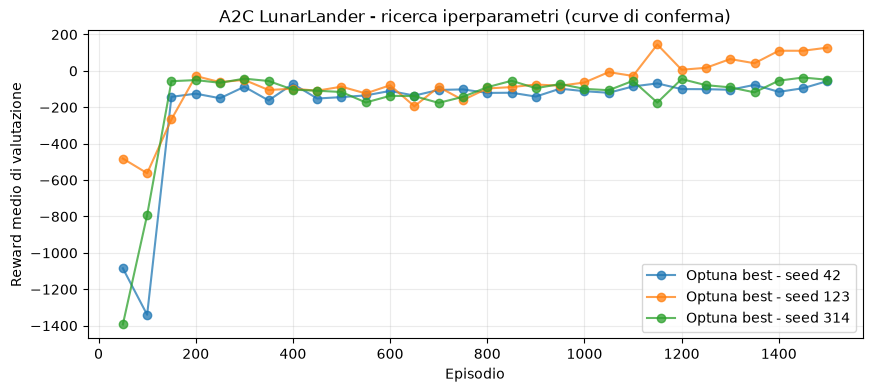

In [6]:
plt.figure(figsize=(10, 4))

for output in confirmation_outputs:
    if output.training_result.eval_episodes is not None:
        plt.plot(
            output.training_result.eval_episodes,
            output.training_result.eval_mean_rewards,
            marker="o",
            alpha=0.75,
            label=f"Optuna best - seed {output.seed}",
        )

plt.xlabel("Episodio")
plt.ylabel("Reward medio di valutazione")
plt.title("A2C LunarLander - ricerca iperparametri (curve di conferma)")
plt.grid(alpha=0.25)
plt.legend()
plt.show()